# Customer Personality Segmentation

## 1. Business Objective

The objective of this project is to segment retail customers based on demographic, behavioral, spending, and campaign-response characteristics.

Customer segmentation can help the business:

- Design personalized marketing campaigns
- Improve customer retention
- Identify high-value customer groups
- Optimize promotional strategies
- Improve customer experience through targeted offers

K-Means clustering is used to group customers with similar characteristics into distinct customer segments.

## 2. Import Libraries

In [3]:
# Check Python environment
import sys
print(sys.executable)

# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing and modeling
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# For timing model fitting
import time

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Visualization style
sns.set(style="whitegrid")

/Users/rainauyeung/opt/anaconda3/envs/customer-segmentation/bin/python


## 3. Load Data

The dataset is loaded from the local `data` folder. The file is tab-separated, so `sep="\t"` is used when reading the CSV file.

In [4]:
# Load the dataset
data = pd.read_csv("../data/Customer_Personality_Segmentation.csv", sep="\t")

# Create a working copy
df = data.copy()

# Preview the data
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [5]:
# Check dataset shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 2240
Number of columns: 29


## 4. Data Overview

This section reviews the structure of the dataset, including column names, data types, non-null counts, and memory usage.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

### Observations

- The dataset contains customer demographic, purchase behavior, campaign response, and customer engagement variables.
- Most variables are numerical.
- `Education`, `Marital_Status`, and `Dt_Customer` are stored as object columns.
- `Dt_Customer` should be converted to datetime format before feature engineering.
- The `Income` column contains missing values and requires treatment.

## 5. Summary Statistics

Summary statistics are used to understand the central tendency, spread, and range of numerical variables.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [8]:
average_income = df["Income"].mean()
print(f"Average household income: ${average_income:,.2f}")

Average household income: $52,247.25


### Observations

- The average household income is approximately $52,247 before missing value treatment.
- Income and spending variables show wide ranges, indicating possible customer diversity and potential outliers.
- `Z_CostContact` and `Z_Revenue` appear to be constant columns and will not be useful for clustering.
- Since K-Means is distance-based, numerical variables need to be scaled before modeling.

## 6. Data Cleaning

### 6.1 Missing Value Assessment and Treatment

Missing values are checked before analysis and modeling because incomplete records can affect statistical summaries, visualizations, and clustering results.

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Income    24
dtype: int64

In [10]:
# Treat missing values in Income using median imputation
median_income = df["Income"].median()
df["Income"] = df["Income"].fillna(median_income)

# Verify missing values after treatment
df.isnull().sum().sum()

np.int64(0)

### Observations

- Missing values were found only in the `Income` column.
- Median imputation was used because income is usually right-skewed and can contain high-income outliers.
- After imputation, the dataset contains no missing values.

### 6.2 Duplicate Record Check

Duplicate records are checked to ensure that the same customer is not counted multiple times.

In [11]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


In [12]:
# Drop duplicates if any exist
df = df.drop_duplicates()

print(f"Dataset shape after duplicate check: {df.shape}")

Dataset shape after duplicate check: (2240, 29)


### Observations

- Duplicate records were checked before modeling.
- Removing duplicates, if present, ensures that each customer contributes only once to the segmentation model.

## 7. Feature Engineering

Feature engineering is performed to create more meaningful customer-level variables for segmentation.

The new features include:

- `Age`
- `Customer_Tenure`
- `Total_Spend`
- `Total_Purchases`
- `Total_Children`
- `Total_Campaigns_Accepted`

These features make the clustering results more interpretable from a business perspective.

In [13]:
# Convert Dt_Customer to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

# Calculate Age
current_year = df["Dt_Customer"].dt.year.max()
df["Age"] = current_year - df["Year_Birth"]

# Calculate Customer Tenure in days
latest_date = df["Dt_Customer"].max()
df["Customer_Tenure"] = (latest_date - df["Dt_Customer"]).dt.days

# Simplify Marital Status
df["Marital_Status"] = df["Marital_Status"].replace({
    "Married": "In Relationship",
    "Together": "In Relationship",
    "Single": "Single",
    "Divorced": "Single",
    "Widow": "Single",
    "Alone": "Single",
    "Absurd": "Single",
    "YOLO": "Single"
})

# Simplify Education
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

# Spending columns
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

# Total spending
df["Total_Spend"] = df[spending_cols].sum(axis=1)

# Purchase columns
purchase_cols = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

# Total purchases
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Total children at home
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Campaign response columns
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# Total campaigns accepted
df["Total_Campaigns_Accepted"] = df[campaign_cols].sum(axis=1)

# Preview engineered features
df[
    [
        "Age",
        "Customer_Tenure",
        "Total_Spend",
        "Total_Purchases",
        "Total_Children",
        "Total_Campaigns_Accepted"
    ]
].head()

,Age,Customer_Tenure,Total_Spend,Total_Purchases,Total_Children,Total_Campaigns_Accepted
0,57,663,1617,25,0,1
1,60,113,27,6,2,0
2,49,312,776,21,0,0
3,30,139,53,8,1,0
4,33,161,422,19,1,0


In [14]:
engineered_features = [
    "Age",
    "Customer_Tenure",
    "Total_Spend",
    "Total_Purchases",
    "Total_Children",
    "Total_Campaigns_Accepted"
]

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2240.0,45.194196,11.984069,18.0,37.00,44.0,55.0,121.0
Customer_Tenure,2240.0,353.582143,202.122512,0.0,180.75,355.5,529.0,699.0
Total_Spend,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.5,2525.0
Total_Purchases,2240.0,14.862054,7.677173,0.0,8.00,15.0,21.0,44.0
Total_Children,2240.0,0.950446,0.751803,0.0,0.00,1.0,1.0,3.0
Total_Campaigns_Accepted,2240.0,0.446875,0.890543,0.0,0.00,0.0,1.0,5.0


### Observations

- `Age` provides a clearer demographic variable than `Year_Birth`.
- `Customer_Tenure` captures how long each customer has been associated with the company.
- `Total_Spend` summarizes product spending across all categories.
- `Total_Purchases` summarizes total purchase activity across different channels.
- `Total_Children` captures household family structure.
- `Total_Campaigns_Accepted` summarizes customer responsiveness to marketing campaigns.

## 8. Exploratory Data Analysis

### 8.1 Distribution of Numerical Variables

Histograms are used to examine the shape, spread, skewness, and concentration of numerical variables.

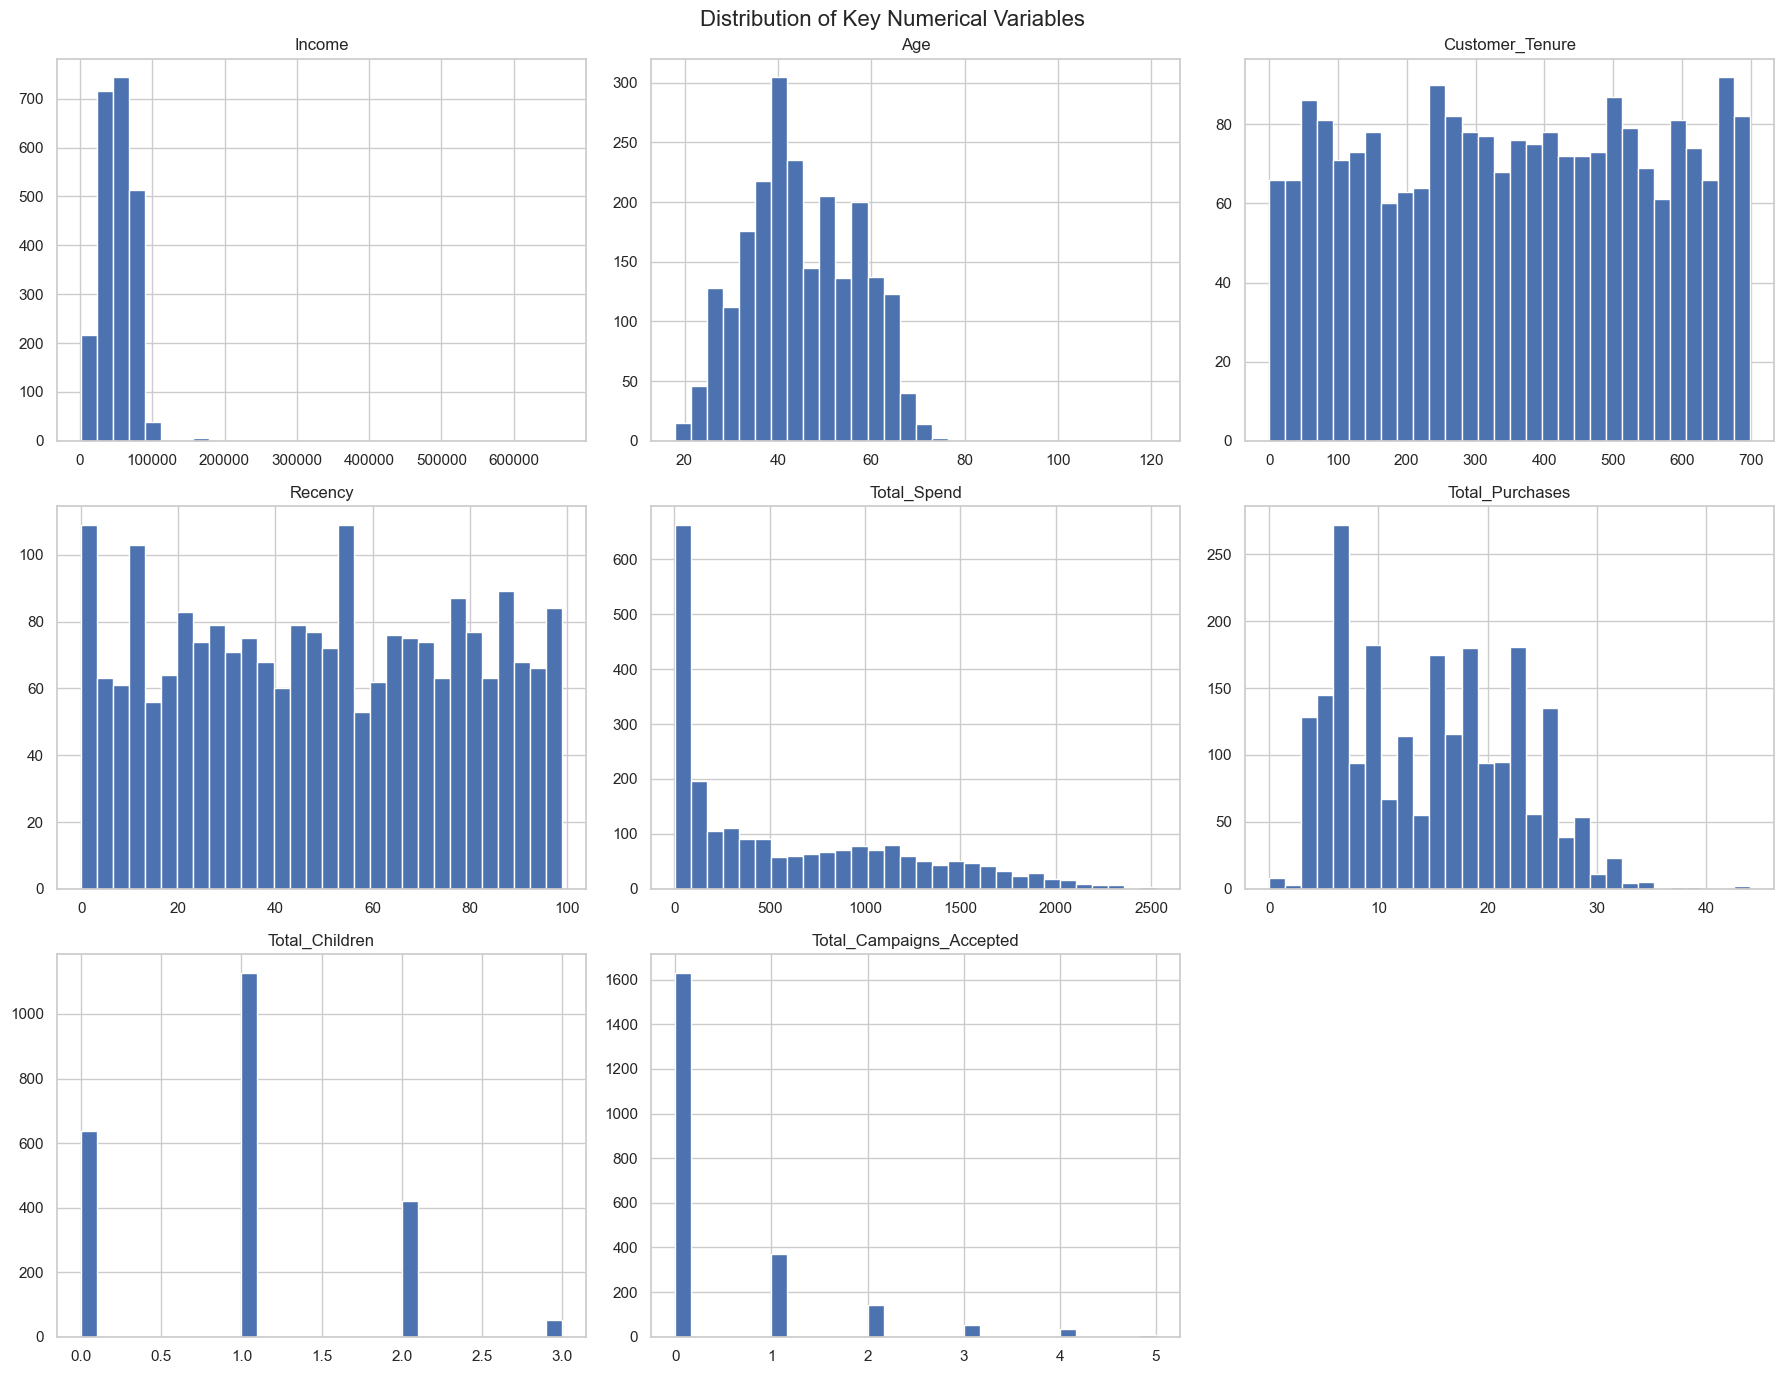

In [15]:
eda_numerical_cols = [
    "Income",
    "Age",
    "Customer_Tenure",
    "Recency",
    "Total_Spend",
    "Total_Purchases",
    "Total_Children",
    "Total_Campaigns_Accepted"
]

df[eda_numerical_cols].hist(figsize=(18, 14), bins=30)
plt.suptitle("Distribution of Key Numerical Variables", fontsize=16)
plt.tight_layout()
plt.savefig("../reports/figures/distribution_of_numerical_variables.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- `Income` and `Total_Spend` are right-skewed, indicating that most customers are in the low-to-mid income and spending ranges, while a smaller group of customers has very high income or spending.
- `Recency` appears relatively evenly distributed, meaning customers vary widely in how recently they purchased.
- `Total_Campaigns_Accepted` is highly skewed, suggesting most customers accepted few or no campaigns.
- `Total_Children` shows that most households have zero, one, or two children/teenagers at home.

### 8.2 Outlier Detection Using Boxplots

Boxplots are used to detect potential outliers and compare the spread of key numerical variables.

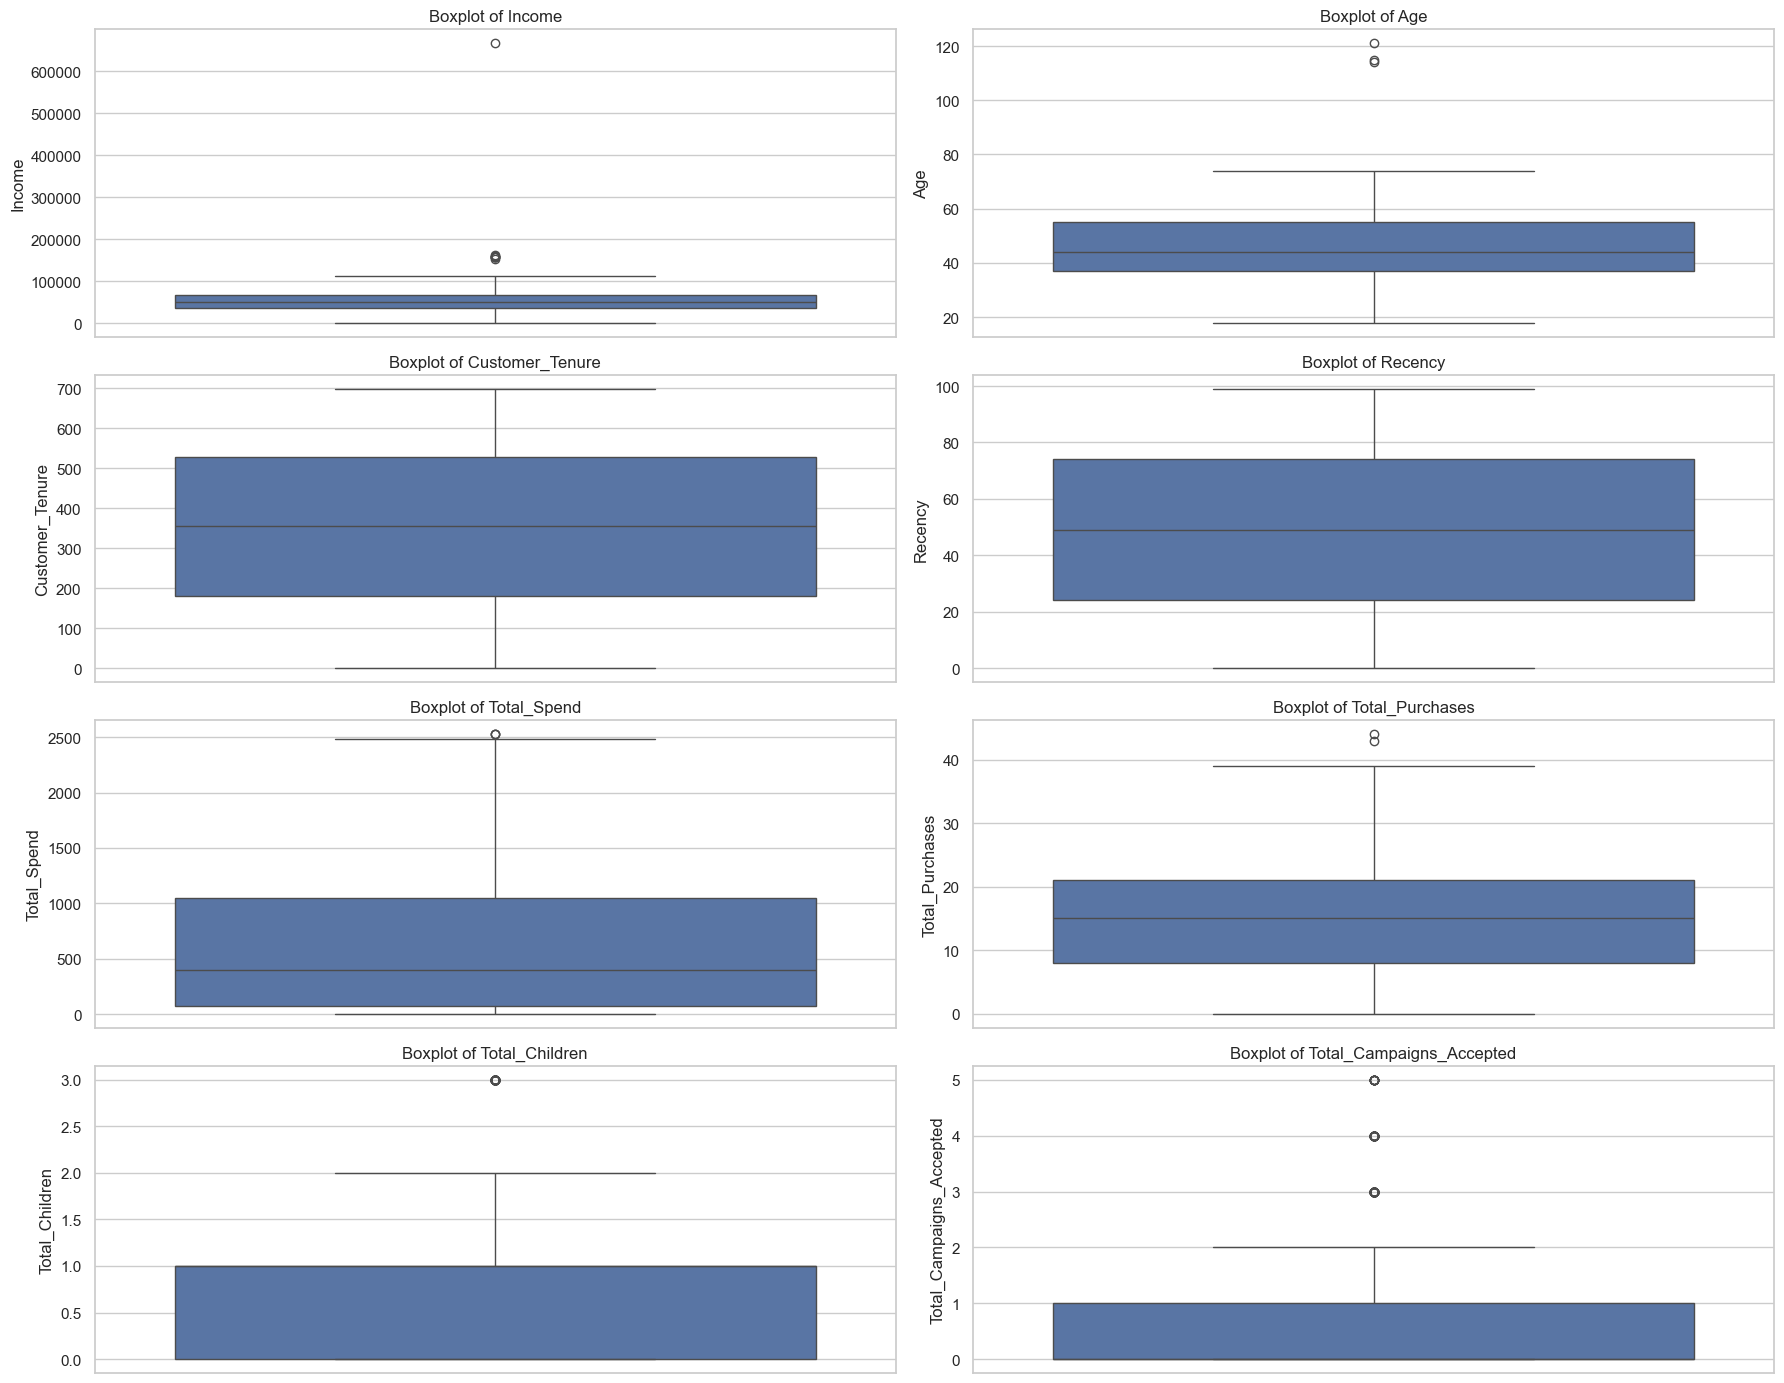

In [16]:
plt.figure(figsize=(18, 14))

for i, col in enumerate(eda_numerical_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df, y=col)
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig("../reports/figures/outlier.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- `Income` contains high-end outliers.
- `Total_Spend` also has high-end outliers, which may represent valuable high-spending customers rather than data errors.
- `Age` may contain a few unusually old customers.
- Since K-Means is sensitive to scale and distance, feature scaling is required before clustering.

### 8.3 Distribution of Categorical Variables

Categorical variables are reviewed to understand customer education and relationship status composition.

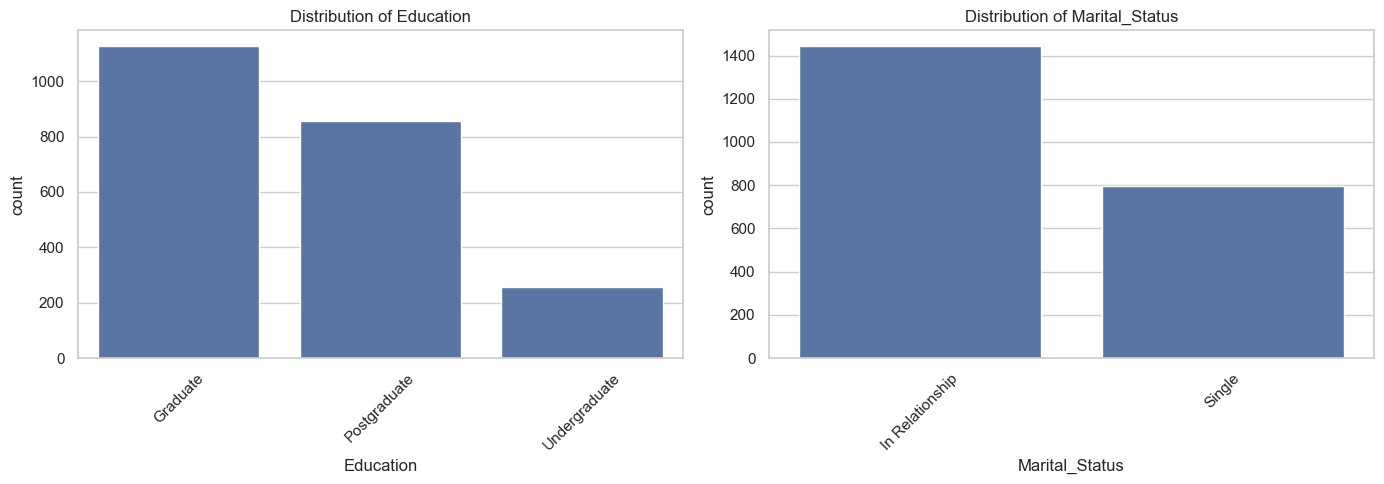

In [17]:
categorical_cols = ["Education", "Marital_Status"]

plt.figure(figsize=(14, 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 2, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../reports/figures/distribution_of_categorical_variables.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Most customers are graduates or postgraduates.
- Most customers are either single or in a relationship after simplifying marital status categories.
- These categorical variables are useful for profiling clusters, even if they are not directly used in the K-Means model.

## 9. Multivariate Analysis

### 9.1 Correlation Analysis

A correlation heatmap is used to examine relationships between numerical variables.

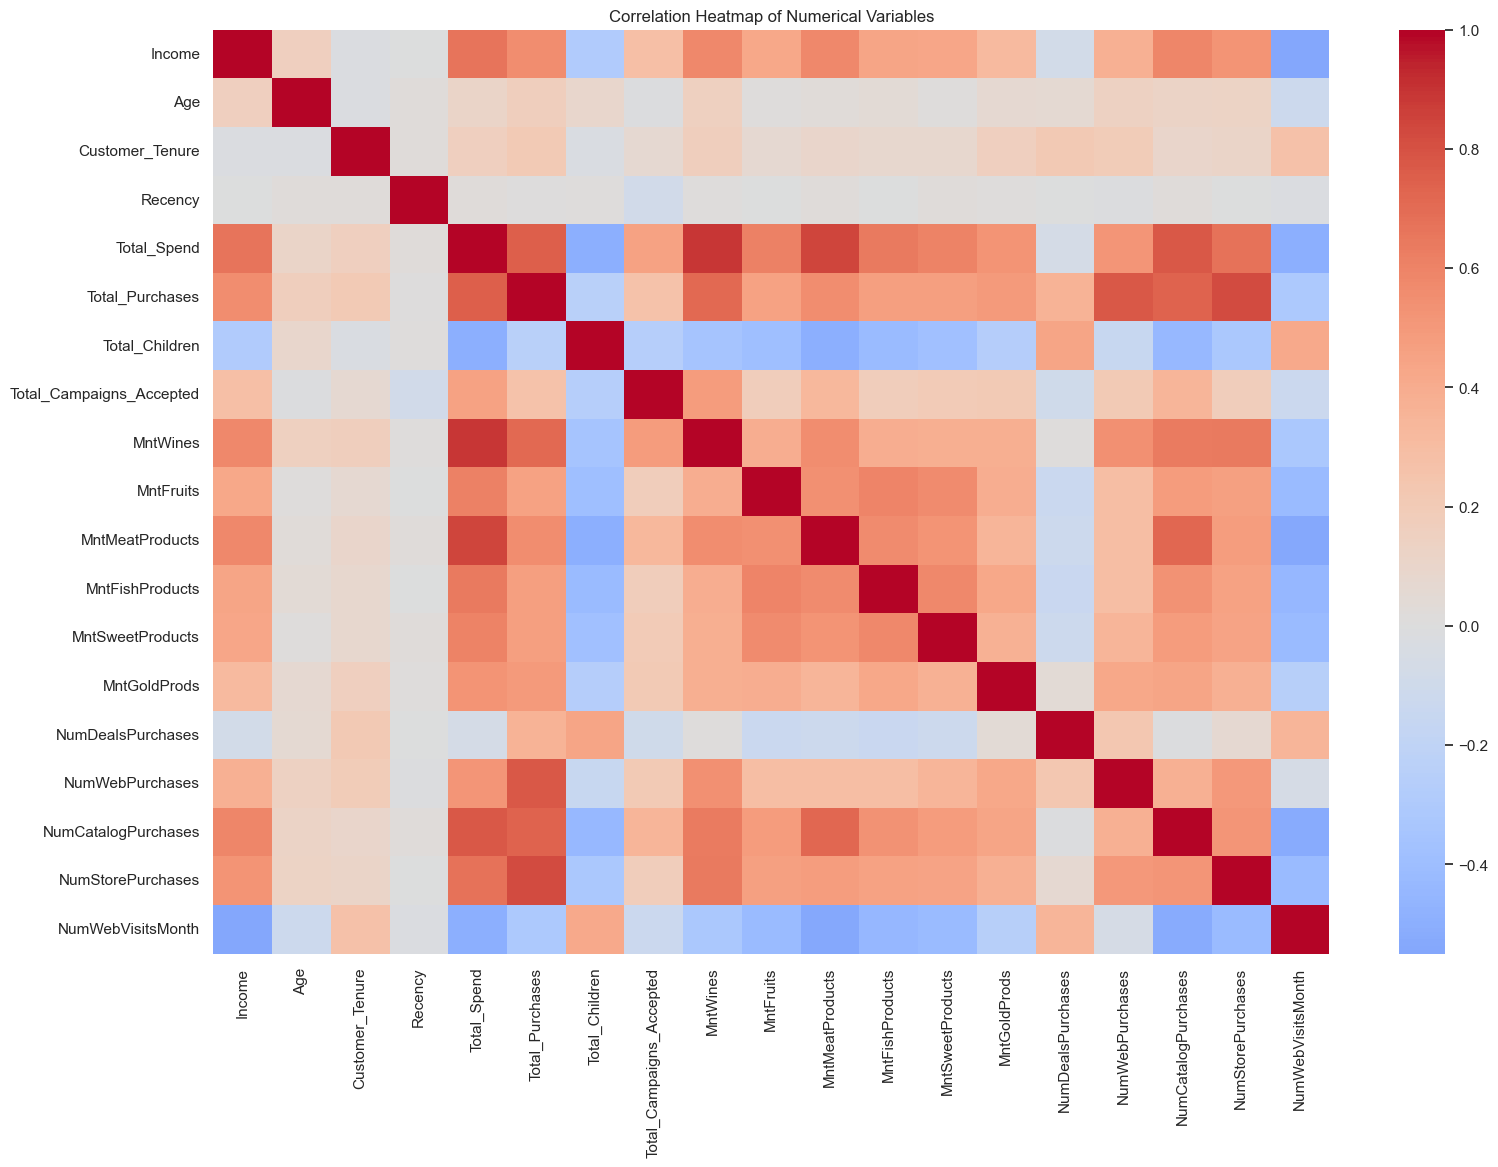

In [18]:
corr_cols = [
    "Income",
    "Age",
    "Customer_Tenure",
    "Recency",
    "Total_Spend",
    "Total_Purchases",
    "Total_Children",
    "Total_Campaigns_Accepted",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

plt.figure(figsize=(18, 12))
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Income and total spending are expected to show a positive relationship.
- Product spending categories are likely correlated with total spending.
- Purchase channel variables can reveal how customers prefer to shop.
- Some variables may contain overlapping information, which is why engineered features are used to simplify the clustering input.

### 9.2 Income vs Total Spending

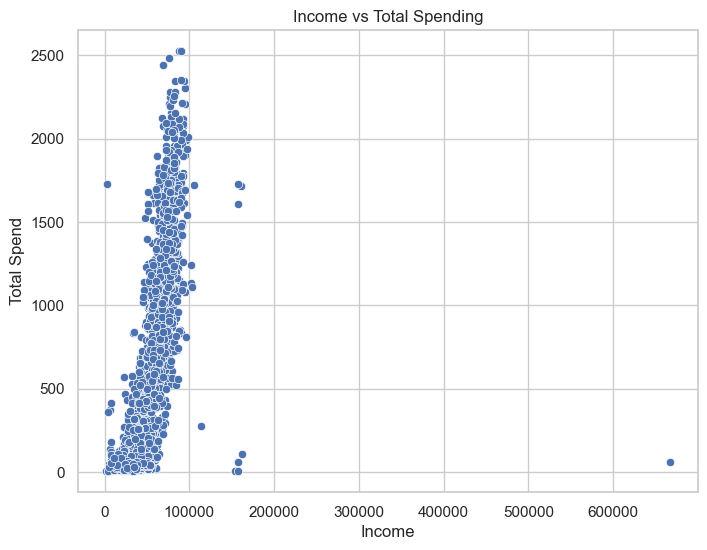

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Income", y="Total_Spend")
plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spend")
plt.savefig("../reports/figures/income_vs_total_spending.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Customers with higher income generally tend to spend more.
- However, not all high-income customers are high spenders, which supports the need for segmentation.
- This relationship can help identify high-value customers and potential growth opportunities.

## 10. Data Preprocessing for Clustering

The clustering model uses engineered customer-level features that summarize demographics, loyalty, spending, purchase activity, household structure, and campaign responsiveness.

The selected features are:

- `Income`
- `Age`
- `Customer_Tenure`
- `Total_Spend`
- `Recency`
- `Total_Purchases`
- `Total_Children`
- `Total_Campaigns_Accepted`

These features are scaled using standardization because K-Means relies on distance calculations.

In [21]:
features = [
    "Income",
    "Age",
    "Customer_Tenure",
    "Total_Spend",
    "Recency",
    "Total_Purchases",
    "Total_Children",
    "Total_Campaigns_Accepted"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.23569584,  0.98534473,  1.53118494,  1.67941681,  0.30703926,
         1.32082612, -1.2645053 ,  0.62124825],
       [-0.23545419,  1.23573295, -1.19054458, -0.96127545, -0.38366418,
        -1.15459595,  1.39636071, -0.50191242],
       [ 0.77399892,  0.3176428 , -0.20577336,  0.28267329, -0.79808624,
         0.79968463, -1.2645053 , -0.50191242],
       [-1.02235542, -1.26814929, -1.06188101, -0.91809432, -0.79808624,
        -0.8940252 ,  0.06592771, -0.50191242],
       [ 0.24188782, -1.01776106, -0.95301182, -0.30525442,  1.55030546,
         0.53911389,  0.06592771, -0.50191242]])

## 11. K-Means Clustering

### 11.1 Selecting the Number of Clusters Using the Elbow Method

The elbow method compares model inertia across different values of \(k\). The goal is to identify the point where adding more clusters results in only a small reduction in inertia.

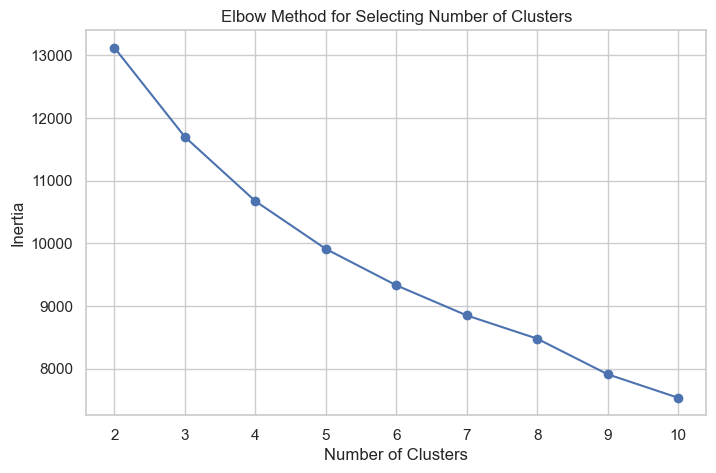

In [22]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.grid(True)
plt.savefig("../reports/figures/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
elbow_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Inertia": inertia
})

elbow_results

,Number of Clusters,Inertia
0,2,13120.961036
1,3,11697.574971
2,4,10672.290742
3,5,9909.469009
4,6,9328.666630
5,7,8847.922485
6,8,8476.398391
7,9,7908.189790
8,10,7533.148885


### Observations

- Inertia decreases as the number of clusters increases.
- The appropriate number of clusters is usually selected where the curve begins to flatten.
- Based on the elbow plot, \(k = 4\) is selected as a reasonable candidate and will be validated using silhouette scores.

### 11.2 Cluster Validation Using Silhouette Score

Silhouette score measures how well each customer fits within its assigned cluster compared with other clusters. Higher values indicate better-defined clusters.

In [24]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "Number of Clusters": list(k_values),
    "Silhouette Score": silhouette_scores
})

silhouette_results

,Number of Clusters,Silhouette Score
0,2,0.255767
1,3,0.226720
2,4,0.174147
3,5,0.163476
4,6,0.153081
5,7,0.157698
6,8,0.149529
7,9,0.155760
8,10,0.155354


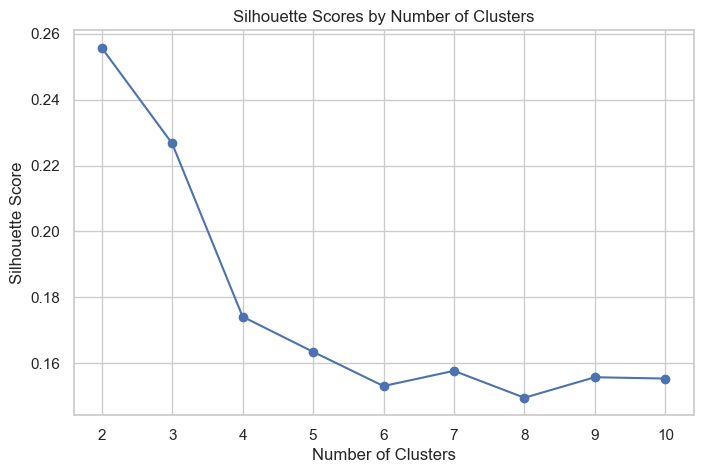

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by Number of Clusters")
plt.grid(True)
plt.savefig("../reports/figures/cluster_validation.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
best_k_silhouette = silhouette_results.loc[
    silhouette_results["Silhouette Score"].idxmax(),
    "Number of Clusters"
]

print(f"Best number of clusters based on silhouette score: {best_k_silhouette}")

Best number of clusters based on silhouette score: 2


### Observations

- The silhouette score provides another way to evaluate cluster quality.
- If the elbow method and silhouette score suggest the same value of \(k\), that strengthens the choice.
- If they suggest different values, the final number of clusters should balance statistical performance with business interpretability.
- For this project, \(k = 4\) is selected because it provides an interpretable customer segmentation structure.

### 11.3 Final K-Means Model

The final K-Means model is fitted using the selected number of clusters. Model fitting time is recorded to evaluate computational efficiency.

In [27]:
optimal_k = 4

start_time = time.time()

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = final_kmeans.fit_predict(X_scaled)

end_time = time.time()

fit_time = end_time - start_time

print(f"Model fitting time: {fit_time:.4f} seconds")

Model fitting time: 0.0538 seconds


In [28]:
df[features + ["Cluster"]].head()

,Income,Age,Customer_Tenure,Total_Spend,Recency,Total_Purchases,Total_Children,Total_Campaigns_Accepted,Cluster
0,58138.0,57,663,1617,58,25,0,1,3
1,46344.0,60,113,27,38,6,2,0,0
2,71613.0,49,312,776,26,21,0,0,3
3,26646.0,30,139,53,26,8,1,0,2
4,58293.0,33,161,422,94,19,1,0,3


### Observations

- The final K-Means model assigned each customer to one of four clusters.
- Model fitting was computationally efficient.
- The cluster labels are used for customer profiling and business interpretation.

## 12. Cluster Profiling and Interpretation

### 12.1 Cluster Size Distribution

The number of customers in each cluster is reviewed to understand the size and balance of each segment.

In [29]:
cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_percentages = (df["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2)

cluster_size_summary = pd.DataFrame({
    "Customer_Count": cluster_counts,
    "Percentage": cluster_percentages
})

cluster_size_summary

,Customer_Count,Percentage
Cluster,,
0,528,23.57
1,222,9.91
2,668,29.82
3,822,36.70


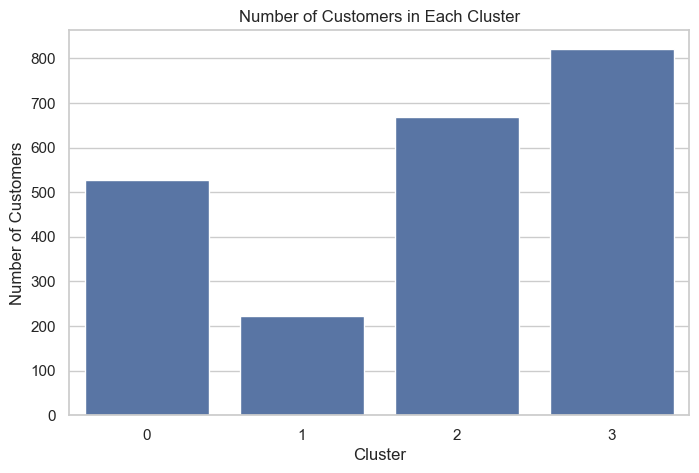

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Cluster")
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig("../reports/figures/no_of_customers.png", dpi=300, bbox_inches="tight")
plt.show()

### 12.2 Cluster Summary Table

A cluster summary table is created to compare the average characteristics of each customer segment.

In [31]:
cluster_profile = df.groupby("Cluster")[features].mean().round(2)

cluster_profile["Customer_Count"] = df["Cluster"].value_counts().sort_index()

cluster_profile

,Income,Age,Customer_Tenure,Total_Spend,Recency,Total_Purchases,Total_Children,Total_Campaigns_Accepted,Customer_Count
Cluster,,,,,,,,,
0,44269.96,51.07,290.49,169.99,50.94,10.47,1.84,0.17,528
1,80775.29,42.67,388.50,1559.96,43.18,20.85,0.24,2.53,222
2,31174.01,37.00,354.38,118.48,47.56,8.14,0.83,0.19,668
3,66766.63,48.76,384.03,1024.06,50.80,21.53,0.67,0.27,822


In [32]:
overall_profile = df[features].mean().round(2)
overall_profile

Income                      52237.98
Age                            45.19
Customer_Tenure               353.58
Total_Spend                   605.80
Recency                        49.11
Total_Purchases                14.86
Total_Children                  0.95
Total_Campaigns_Accepted        0.45
dtype: float64

### Observations

- The cluster summary table helps identify which clusters have higher income, spending, purchase frequency, tenure, or campaign responsiveness.
- Segment names should be assigned based on the actual values in this table.
- Cluster numbers do not have inherent meaning; interpretation must be based on the profile of each cluster.

### 12.3 Cluster Profiling Using Boxplots

Boxplots are used to compare distributions of key clustering features across customer segments.

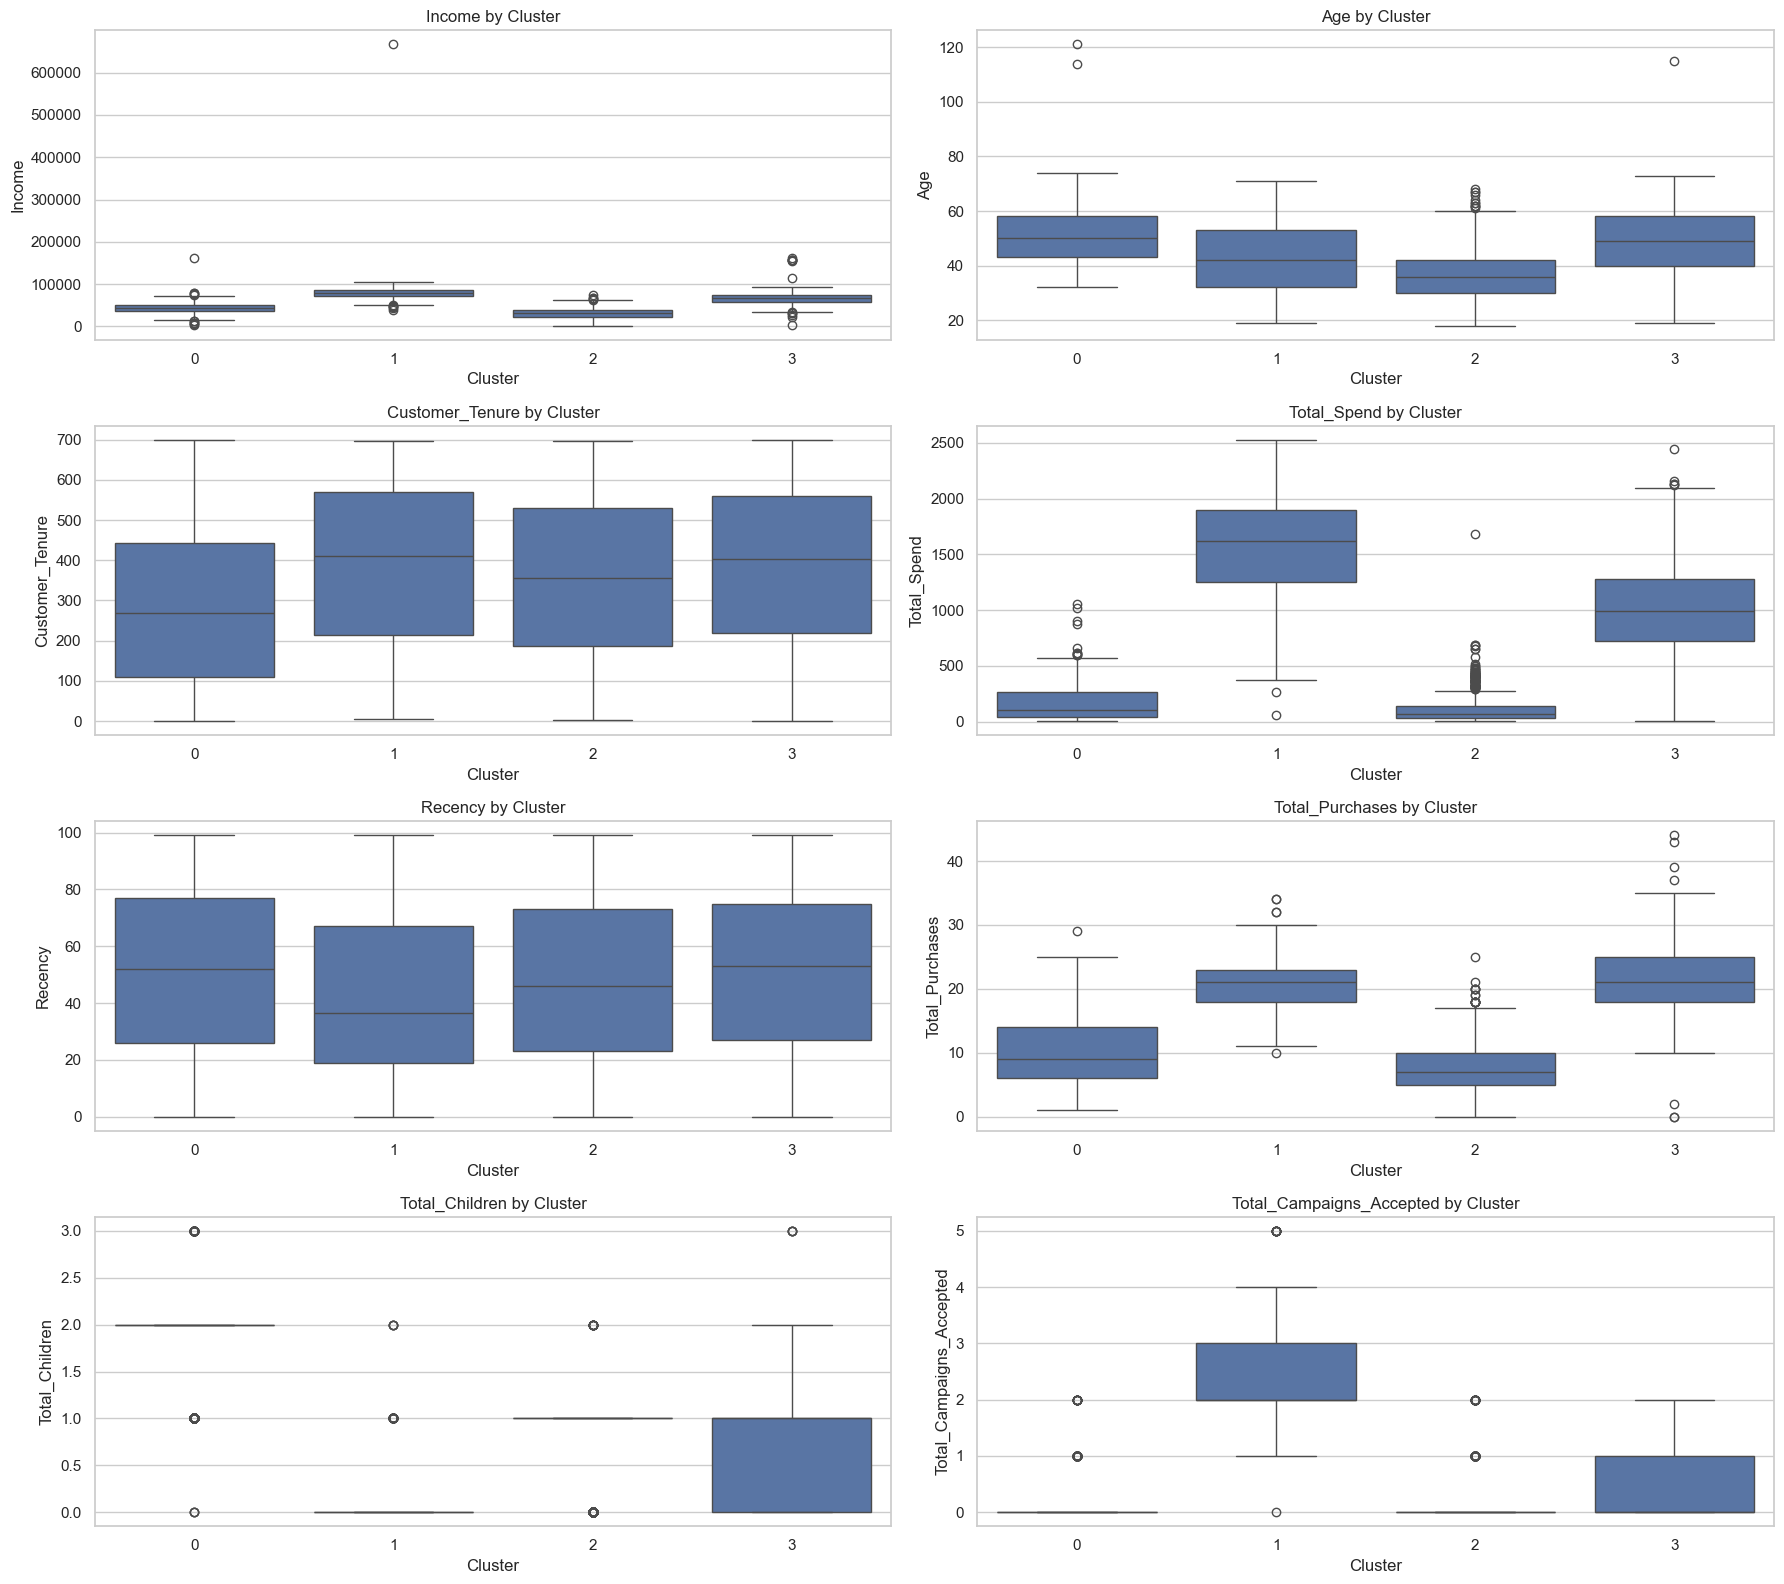

In [34]:
plt.figure(figsize=(18, 16))

for i, col in enumerate(features, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df, x="Cluster", y=col)
    plt.title(f"{col} by Cluster")

plt.tight_layout()
plt.savefig("../reports/figures/cluster_profilling.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- The clusters show clear differences in income, total spending, purchase frequency, household structure, and campaign responsiveness.
- Some clusters represent higher-value customers with stronger spending and purchase behavior.
- Other clusters may represent budget-conscious or less engaged customers.

### 12.4 Product and Channel Profiling

Product and purchase-channel variables are used to further understand the behavior of each cluster.

In [35]:
product_channel_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

product_channel_profile = df.groupby("Cluster")[product_channel_cols].mean().round(2)
product_channel_profile

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,
0,98.20,5.22,35.08,7.08,5.22,19.18,2.84,2.83,0.88,3.92,5.99
1,832.61,56.88,455.34,78.42,60.36,76.34,1.41,5.77,5.78,7.89,3.69
2,41.83,7.41,31.50,10.59,7.19,19.96,1.88,2.34,0.60,3.32,6.68
3,506.31,46.94,283.84,67.92,48.25,70.80,2.61,5.85,4.64,8.43,4.21


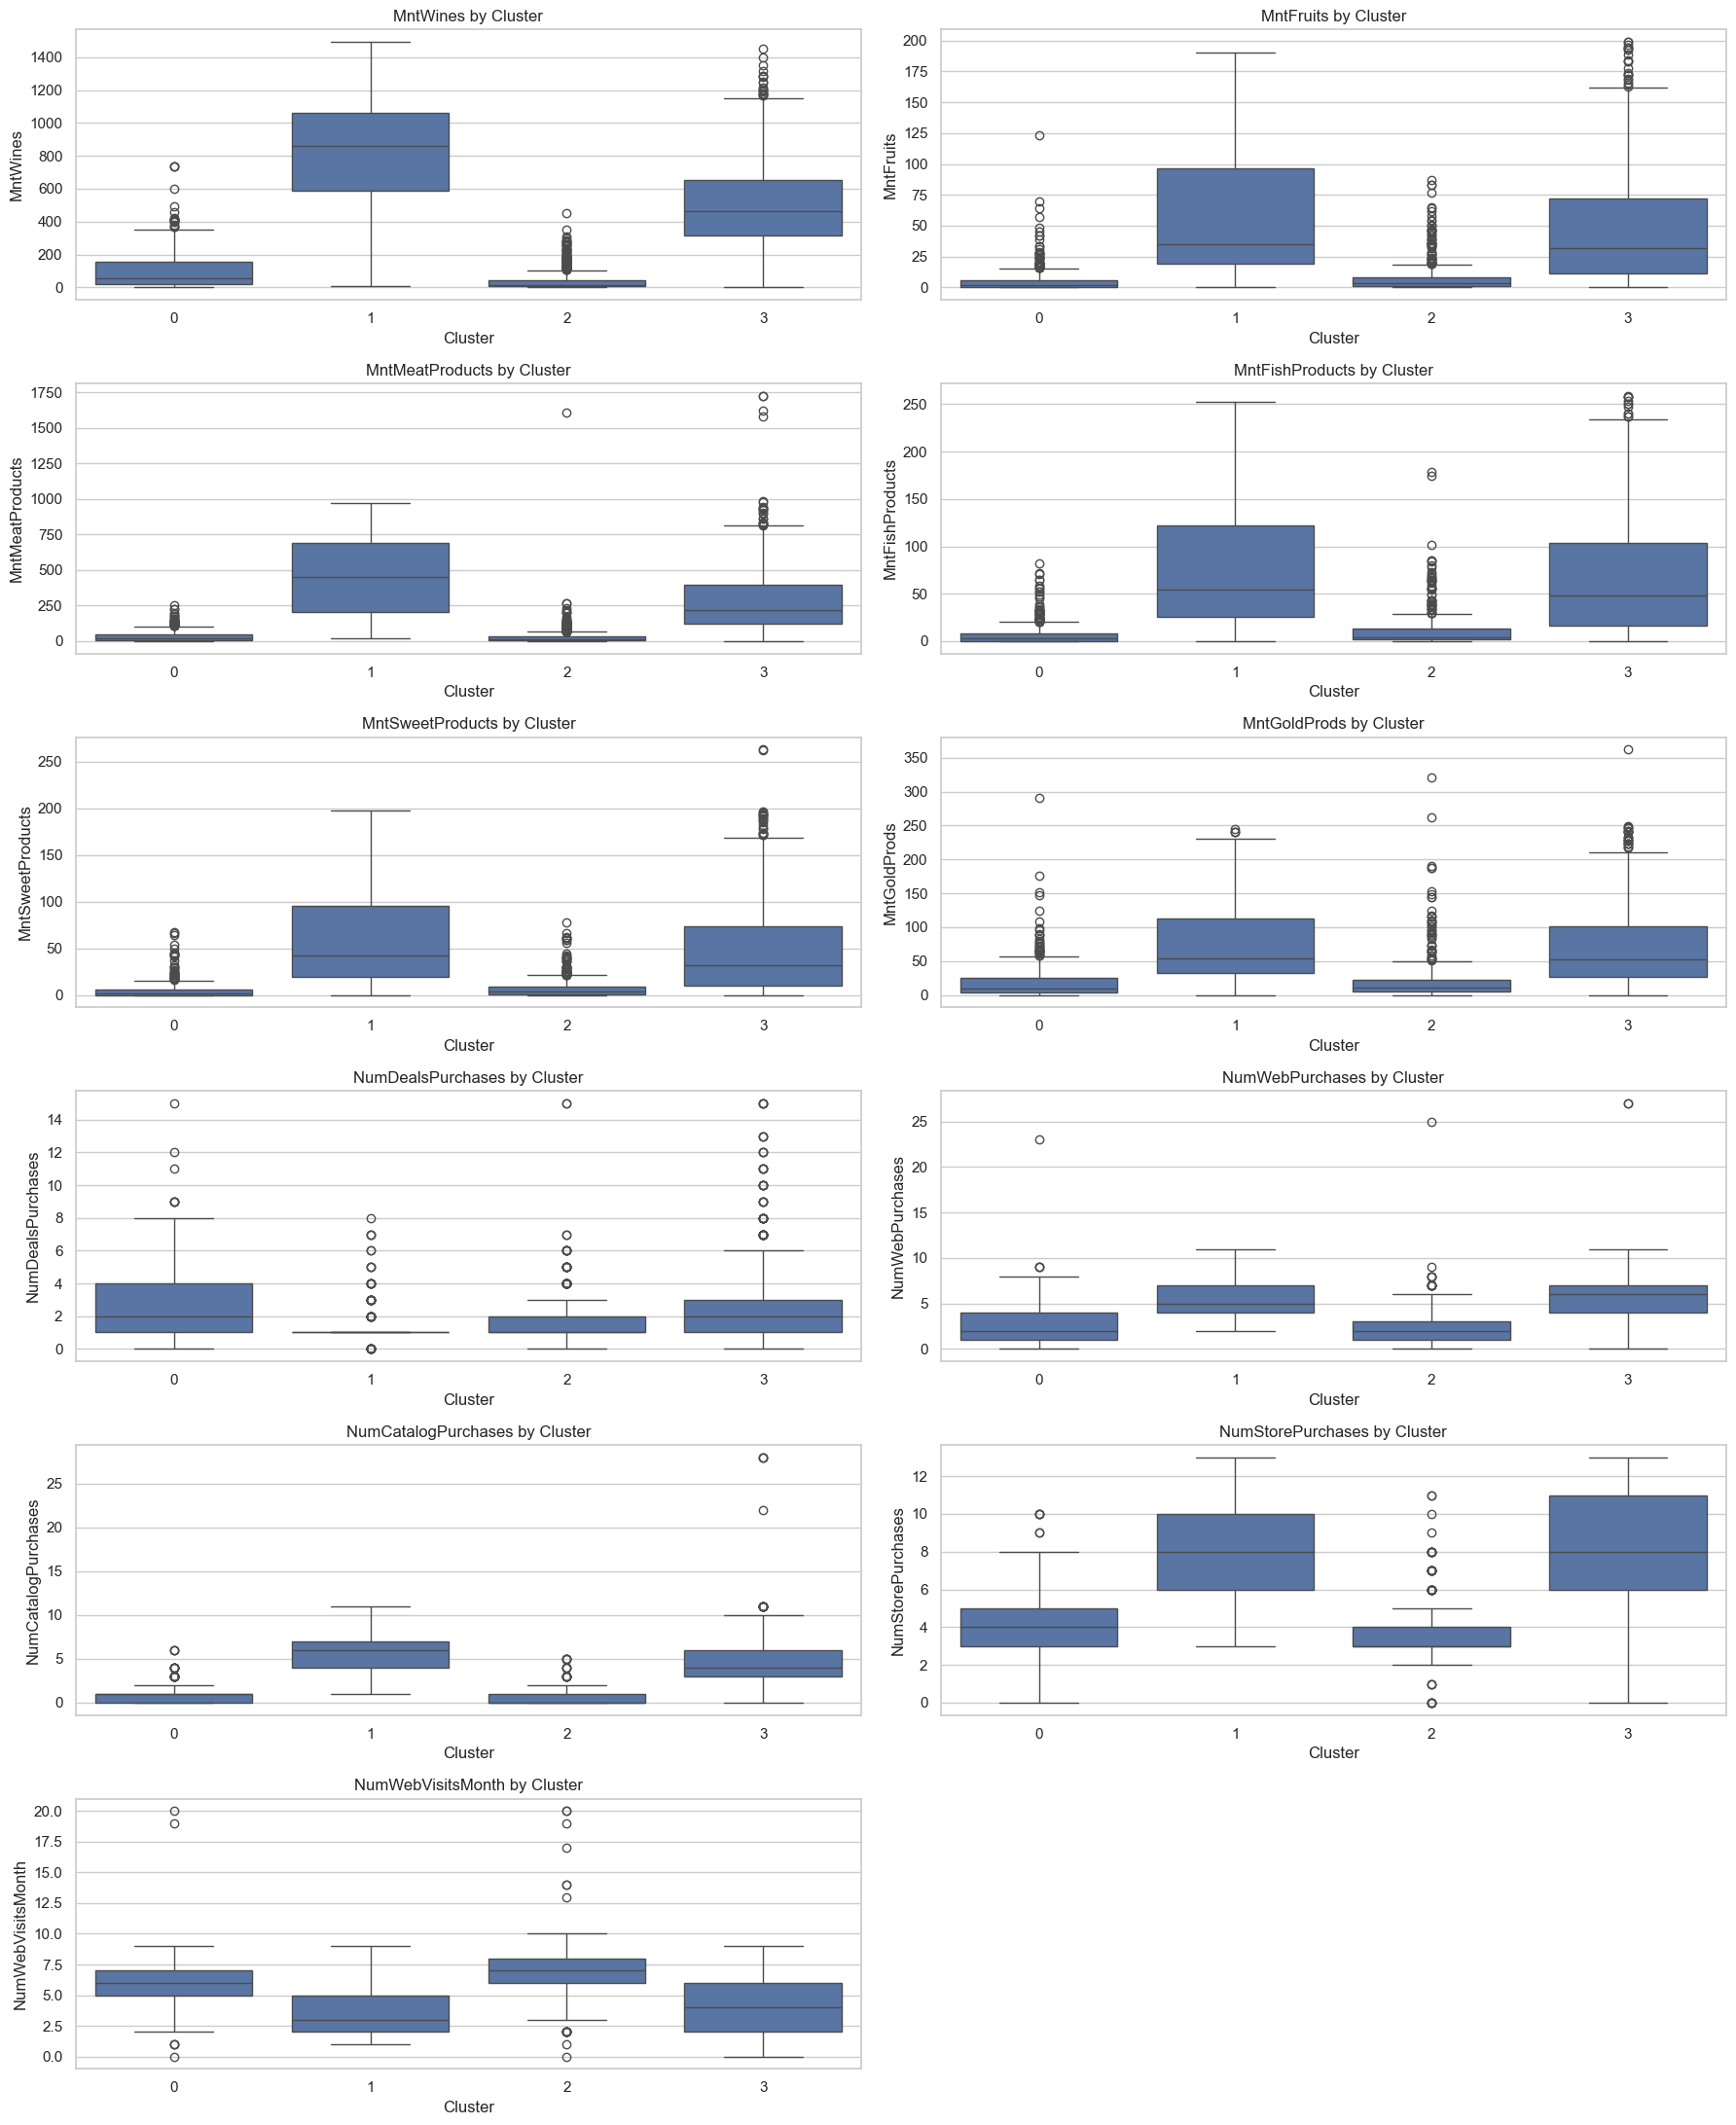

In [36]:
plt.figure(figsize=(18, 22))

for i, col in enumerate(product_channel_cols, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(data=df, x="Cluster", y=col)
    plt.title(f"{col} by Cluster")

plt.tight_layout()
plt.savefig("../reports/figures/product_and_channel_profilling.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Product-level spending helps identify which clusters prefer wine, meat, fruits, fish, sweets, or gold products.
- Purchase-channel behavior helps distinguish store, catalog, web, and deal-driven customers.
- These variables are especially useful for designing targeted marketing strategies.

### 12.5 Categorical Profiling

Education and marital status are reviewed across clusters to provide additional demographic context.

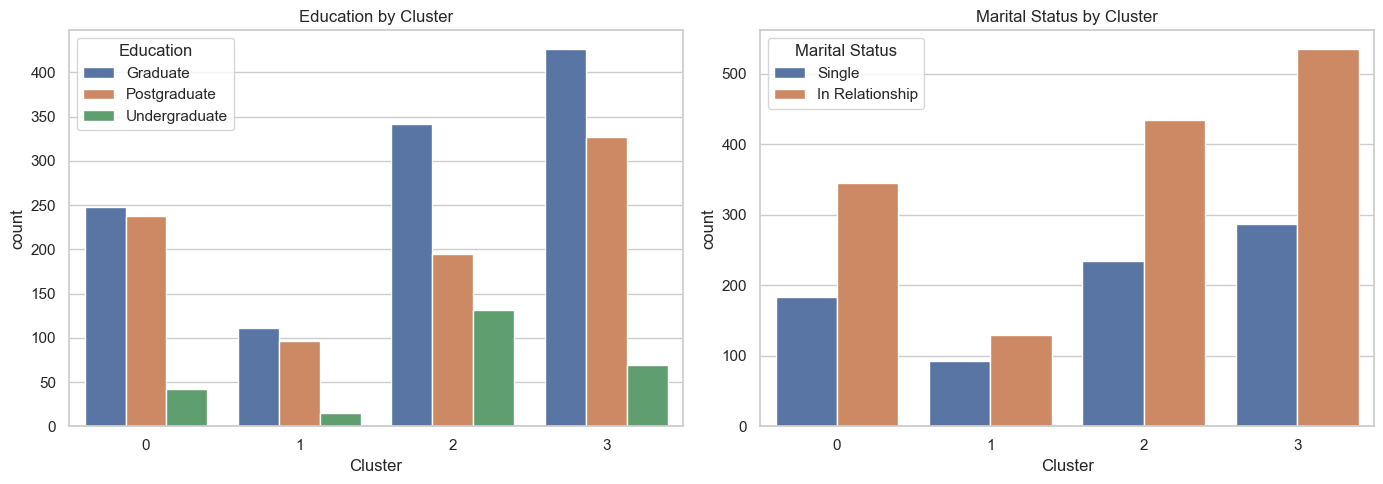

In [37]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x="Cluster", hue="Education")
plt.title("Education by Cluster")
plt.legend(title="Education")

plt.subplot(1, 2, 2)
sns.countplot(data=df, x="Cluster", hue="Marital_Status")
plt.title("Marital Status by Cluster")
plt.legend(title="Marital Status")

plt.tight_layout()
plt.savefig("../reports/figures/categorical_profilling.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Customer Segment Summary

The final cluster names should be based on the cluster summary table and boxplots. The table below provides a business-friendly interpretation of the four customer segments.

| Cluster | Suggested Segment Name | Key Characteristics | Suggested Strategy |
|---|---|---|---|
| 0 | Budget-Conscious Customers | Lower income, lower spending, higher family responsibility, lower campaign response | Use discounts, bundles, and value-based promotions |
| 1 | High-Value Loyal Customers | Higher income, higher total spending, frequent purchases, strong value potential | Offer VIP rewards, premium products, and loyalty benefits |
| 2 | Steady Mid-Value Customers | Moderate income, moderate spending, stable purchase activity | Encourage upselling and cross-selling through personalized offers |
| 3 | Recently Active Growth Customers | Recent purchases, moderate spending, potential for future growth | Use digital engagement, onboarding offers, and retention campaigns |

### Important Note

Cluster numbers can change depending on the selected features and model initialization. The segment names above should be confirmed using the actual cluster summary table generated in the notebook.

## 14. Business Recommendations

Based on the customer segments identified through K-Means clustering, the business can design more targeted strategies for each group.

### Segment 1: Budget-Conscious Customers

These customers generally have lower income and lower total spending. They may also have more children at home, making them more price-sensitive.

Recommended actions:

- Promote discounts, coupons, and bundle offers.
- Emphasize value-for-money products.
- Use family-oriented promotions.
- Avoid expensive premium campaigns for this group.

---

### Segment 2: High-Value Loyal Customers

These customers have higher income and higher spending. They are important to retain because they contribute significantly to revenue.

Recommended actions:

- Create VIP loyalty programs.
- Offer early access to premium products.
- Provide personalized recommendations.
- Use exclusive campaigns for luxury or high-margin products.
- Focus on retention because losing these customers would have a high revenue impact.

---

### Segment 3: Steady Mid-Value Customers

These customers show moderate spending and stable purchase behavior. They represent an opportunity for incremental revenue growth.

Recommended actions:

- Use cross-selling and upselling strategies.
- Recommend products related to their current purchase habits.
- Offer moderate incentives to increase basket size.
- Encourage loyalty program participation.

---

### Segment 4: Recently Active Growth Customers

These customers may have purchased recently and show potential for stronger future engagement.

Recommended actions:

- Use follow-up campaigns shortly after purchase.
- Encourage repeat purchases through personalized offers.
- Promote digital campaigns and online-exclusive deals.
- Track behavior over time to identify customers who can move into higher-value segments.

## 15. Conclusion

This project used K-Means clustering to segment customers based on demographic, spending, behavioral, and campaign-response characteristics.

The analysis showed that customers can be grouped into meaningful segments with different income levels, spending habits, purchase activity, family structures, and marketing responsiveness.

Key outcomes:

- Missing income values were treated using median imputation.
- New customer-level features were created to improve interpretability.
- The elbow method and silhouette score were used to evaluate the appropriate number of clusters.
- A final K-Means model with four clusters was fitted.
- Cluster profiling revealed distinct customer groups that can support targeted marketing strategies.

These customer segments can help the business improve marketing efficiency, personalize offers, increase customer retention, and better allocate resources.